# Modelo de Churn — Base Real (`abt_churn.csv`)

Aplicação do pipeline elaborado no notebook anterior (feature engineering dentro da pipeline, avaliação aprofundada e SHAP avançado) a uma base **real** de churn, no formato de ABT mensal por usuário.

Duas diferenças importantes em relação à base sintética anterior:

- **Sinal real.** Aqui as features têm correlação de fato com o target (até ~0.48 em módulo) — as métricas de rank vão sair muito acima do nível de base, ao contrário do notebook anterior.
- **Estrutura em painel.** Cada usuário (`idUsuario`) pode aparecer em várias fotografias mensais (`dtRef`). Isso exige um cuidado que a base sintética não tinha: **split fora do tempo (out-of-time)** em vez de aleatório, e validação cruzada por grupo de usuário — para não vazar identidade do usuário nem informação do futuro para o treino.

O restante do pipeline (feature engineering interna, avaliação em múltiplas camadas, SHAP local e global) segue a mesma lógica do notebook anterior.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    brier_score_loss, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve, roc_curve
)
from sklearn.calibration import calibration_curve
import shap

%matplotlib inline
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Carregamento e exploração dos dados

`dtRef` é a data de referência de cada fotografia mensal do usuário; `idUsuario` identifica o usuário; `flagChurn` é o target. As demais colunas são métricas de engajamento/transações em janelas de 7/14/28 dias e comparativos (`propAvg*`) — a base já chega bastante trabalhada (é uma ABT).

In [2]:
df = pd.read_csv('abt_churn.csv', parse_dates=['dtRef'])

print(f"Shape: {df.shape}")
print(f"Período: {df['dtRef'].min().date()} a {df['dtRef'].max().date()} ({df['dtRef'].nunique()} meses)")
print(f"Usuários distintos: {df['idUsuario'].nunique()}")
print(f"Nulos totais: {df.isna().sum().sum()}")
print(f"\nTaxa de churn geral (flagChurn=1): {df['flagChurn'].mean():.1%}")
print(f"\nLinhas por usuário (distribuição):\n{df.groupby('idUsuario').size().describe()}")

Shape: (5496, 43)
Período: 2024-03-01 a 2025-04-01 (14 meses)
Usuários distintos: 2251
Nulos totais: 0

Taxa de churn geral (flagChurn=1): 47.1%

Linhas por usuário (distribuição):
count    2251.000000
mean        2.441582
std         2.390078
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        14.000000
dtype: float64


,linhas,taxa_churn
dtRef,,
2024-03-01 00:00:00,665,48.4%
2024-04-01 00:00:00,528,43.6%
2024-05-01 00:00:00,542,53.1%
2024-06-01 00:00:00,426,39.2%
2024-07-01 00:00:00,422,41.9%
2024-08-01 00:00:00,415,44.8%
2024-09-01 00:00:00,371,43.7%
2024-10-01 00:00:00,349,47.9%
2024-11-01 00:00:00,258,55.8%


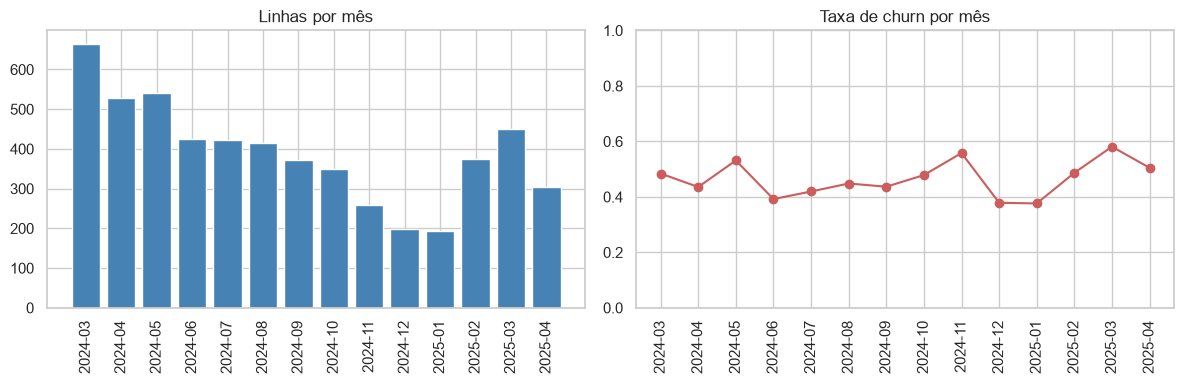

In [3]:
# Volume e taxa de churn por mês -- checagem de estabilidade temporal antes de
# decidir o corte do split out-of-time (queremos meses com volume e taxa
# razoavelmente estáveis, sem quebras óbvias de regra de negócio no meio).
por_mes = df.groupby('dtRef').agg(linhas=('idUsuario', 'size'), taxa_churn=('flagChurn', 'mean'))
rotulos_mes = por_mes.index.strftime('%Y-%m')

display(por_mes.style.format({'taxa_churn': '{:.1%}'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(rotulos_mes, por_mes['linhas'], color='steelblue')
axes[0].set_title('Linhas por mês')
axes[0].tick_params(axis='x', rotation=90)

axes[1].plot(rotulos_mes, por_mes['taxa_churn'], marker='o', color='indianred')
axes[1].set_title('Taxa de churn por mês')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

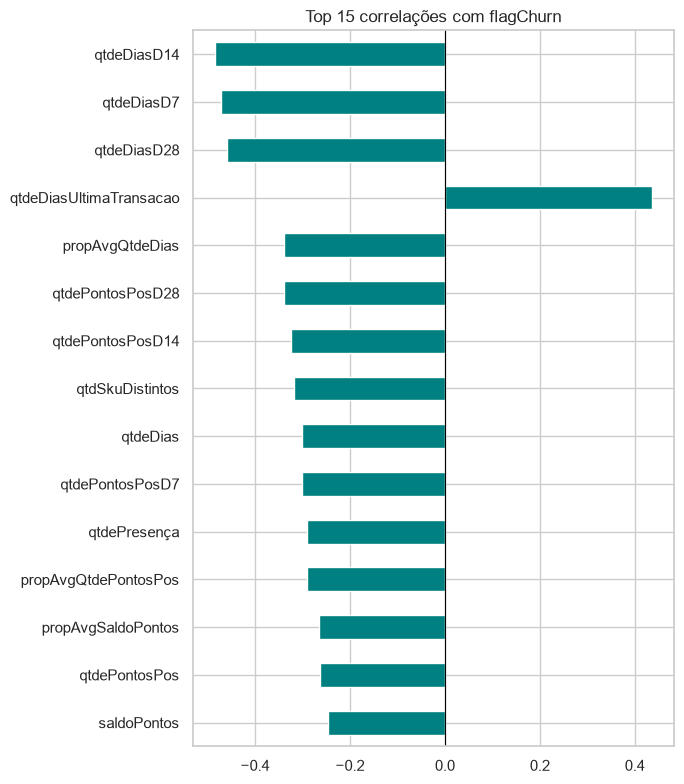

In [4]:
# Correlação simples com o target -- só para orientar a leitura, o modelo não
# usa isso diretamente. Diferente da base sintética, aqui já aparece sinal real.
colunas_numericas = df.select_dtypes('number').columns.drop('flagChurn')
correlacoes = df[colunas_numericas].corrwith(df['flagChurn']).sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 8))
correlacoes.head(15).plot(kind='barh', ax=ax, color='teal')
ax.invert_yaxis()
ax.set_title('Top 15 correlações com flagChurn')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

> ⚠️ **Checar com o time de dados:** a coluna `qtdeChurn` tem nome parecido com o target `flagChurn`, mas a correlação entre elas é baixa (≈ -0.18), então não parece ser o mesmo evento vazado — provavelmente é uma contagem histórica de algum evento de "churn" (ex.: quantas vezes esse usuário já saiu e voltou). Mesmo assim, antes de usar em produção vale confirmar: **esse valor estaria disponível no exato momento em que a previsão seria feita (`dtRef`), ou ele é calculado olhando para o futuro daquela fotografia?** Se for a segunda opção, é vazamento e a coluna deve sair do modelo. Mantive a coluna no pipeline abaixo, mas sinalizando esse ponto explicitamente.

## 2. Split fora do tempo (out-of-time)

Como cada usuário pode aparecer em vários meses, um `train_test_split` aleatório (como no notebook da base sintética) misturaria passado e futuro do mesmo usuário entre treino e teste, e testaria o modelo no mesmo período de tempo em que ele foi treinado — inflando a métrica de forma artificial e escondendo qualquer *drift* temporal.

Em vez disso: **treino = tudo antes do corte; teste = os meses mais recentes**, simulando a situação real de produção (treinar com o passado, prever o futuro). O corte foi escolhido para deixar ~20% dos dados mais recentes no teste (mesma proporção do `test_size=0.2` usado antes).

In [5]:
CORTE = '2025-02-01'  # ~últimos 3 meses da base viram teste (~20% das linhas)

treino_mask = df['dtRef'] < CORTE
teste_mask = ~treino_mask

id_cols = ['dtRef', 'idUsuario']
target_col = 'flagChurn'
feature_cols_raw = [c for c in df.columns if c not in id_cols + [target_col]]

# idUsuario vai junto em X só para servir de "group" na validação cruzada;
# o FeatureEngineer (próxima seção) remove essa coluna antes do modelo.
X_train = df.loc[treino_mask, feature_cols_raw + ['idUsuario']].reset_index(drop=True)
y_train = df.loc[treino_mask, target_col].reset_index(drop=True)
X_test = df.loc[teste_mask, feature_cols_raw + ['idUsuario']].reset_index(drop=True)
y_test = df.loc[teste_mask, target_col].reset_index(drop=True)

grupos_treino = X_train['idUsuario']

usuarios_treino = set(X_train['idUsuario'])
usuarios_teste = set(X_test['idUsuario'])

print(f"Treino: {X_train.shape[0]} linhas ({X_train.shape[0]/len(df):.1%}) | Teste: {X_test.shape[0]} linhas ({X_test.shape[0]/len(df):.1%})")
print(f"Taxa de churn - treino: {y_train.mean():.1%} | teste: {y_test.mean():.1%}")
print(f"Usuários distintos - treino: {len(usuarios_treino)} | teste: {len(usuarios_teste)}")
print(f"Usuários presentes nos dois períodos: {len(usuarios_treino & usuarios_teste)} "
      f"(normal em dado de painel -- o corte é por TEMPO, não por identidade; "
      f"o que importaria seria uma linha futura vazando para o treino, o que não acontece aqui)")

Treino: 4368 linhas (79.5%) | Teste: 1128 linhas (20.5%)
Taxa de churn - treino: 45.6% | teste: 52.9%
Usuários distintos - treino: 1798 | teste: 724
Usuários presentes nos dois períodos: 271 (normal em dado de painel -- o corte é por TEMPO, não por identidade; o que importaria seria uma linha futura vazando para o treino, o que não acontece aqui)


## 3. Feature engineering

A base já chega rica (janelas D7/D14/D28, comparativos `propAvg*`). Mesmo assim, algumas razões e flags ajudam o modelo (e a leitura de negócio) a capturar sinais de queda de engajamento que as colunas brutas não deixam explícitos:

- `razao_atividade_recente`: transações nos últimos 7 dias vs. nos últimos 28 — sinaliza desaceleração recente mesmo quando o volume do mês inteiro ainda parece ok;
- `flag_inativo_7d`: usuário zerou atividade na última semana;
- `pontos_por_transacao`: saldo de pontos por transação — proxy de "valor médio" do usuário;
- `proporcao_gasto_pontos`: quanto do que o usuário ganhou em pontos ele já gastou;
- `recencia_relativa`: dias desde a última transação em relação ao tempo total de vida do usuário na base — a mesma "recência absoluta" pesa diferente para um usuário novo e um antigo.

Assim como no notebook anterior, o transformer é stateless (não usa o target nem estatísticas globais), então pode ser reaplicado em qualquer fold/conjunto sem vazamento.

In [6]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Cria features derivadas e remove a coluna de identificação (idUsuario),
    que só viaja até aqui para servir de 'group' na validação cruzada."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X['razao_atividade_recente'] = X['qtdeTransacoesD7'] / (X['qtdeTransacoesD28'] + 1)
        X['flag_inativo_7d'] = (X['qtdeDiasD7'] == 0).astype(int)
        X['pontos_por_transacao'] = X['saldoPontos'] / (X['qtdeTransacoes'] + 1)
        X['proporcao_gasto_pontos'] = X['qtdePontosNeg'].abs() / (X['qtdePontosPos'] + 1)
        X['recencia_relativa'] = X['qtdeDiasUltimaTransacao'] / (X['qtdeDiasPrimeiraTransacao'] + 1)

        return X.drop(columns=['idUsuario'])


# Pré-visualização das features geradas
FeatureEngineer().fit_transform(X_train.head())

,qtdeTransacoes,qtdeDias,mediaTransacoesDias,saldoPontos,qtdePontosPos,qtdePontosNeg,qtdeDiasUltimaTransacao,qtdeDiasPrimeiraTransacao,qtdSkuDistintos,qtdeChatMessage,...,propAvgQtdeDias,propAvgMediaTransacoesDias,propAvgSaldoPontos,propAvgQtdePontosPos,propAvgQtdePontosNeg,razao_atividade_recente,flag_inativo_7d,pontos_por_transacao,proporcao_gasto_pontos,recencia_relativa
0,266,27,9.851852,635,2635,-2000,1.0,89.0,5,235,...,3.278281,2.135602,1.516314,4.101926,8.944444,0.600000,0,2.378277,0.758725,0.011111
1,268,28,9.571429,686,2686,-2000,4.0,211.0,5,236,...,2.567615,2.328737,1.288278,2.920954,5.167037,0.666667,0,2.550186,0.744325,0.018868
2,188,11,17.090909,275,1275,-1000,3.0,28.0,5,175,...,1.820201,3.739048,0.798622,2.634551,7.162791,0.375661,0,1.455026,0.783699,0.103448
3,262,24,10.916667,484,2484,-2000,2.0,58.0,5,234,...,3.255244,2.322640,1.275749,4.275765,9.922414,0.183099,0,1.840304,0.804829,0.033898
4,1,1,1.000000,50,50,0,21.0,21.0,1,0,...,0.103973,0.236635,0.104533,0.063302,0.000000,0.000000,1,25.000000,0.000000,0.954545


## 4. Pipeline de pré-processamento e modelo

Diferente da base sintética, aqui não há colunas categóricas (tudo numérico), então o `ColumnTransformer` com dois ramos não é necessário — mas o padrão continua reaproveitável se um dia entrar uma coluna categórica (ex.: plano, canal de aquisição): bastaria plugar o bloco `categorical_transformer` do notebook anterior.

In [7]:
model_pipeline = Pipeline(steps=[
    ('feature_engineering', FeatureEngineer()),
    ('imputer', SimpleImputer(strategy='median')),   # não há nulos hoje, mas protege a pipeline em produção
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=15,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive esti

## 5. Validação cruzada por grupo (dentro do período de treino)

`StratifiedGroupKFold` em vez do `StratifiedKFold` simples do notebook anterior: mantém a proporção de classes em cada fold **e** garante que todas as linhas do mesmo `idUsuario` fiquem do mesmo lado (treino ou validação) em cada fold — sem isso, duas fotografias do mesmo usuário em meses próximos poderiam cair uma em treino e outra em validação, inflando a métrica por "memorização" do usuário em vez de generalização.

In [8]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['roc_auc', 'average_precision', 'f1']

cv_results = cross_validate(model_pipeline, X_train, y_train, cv=cv, groups=grupos_treino, scoring=scoring)

print("Validação cruzada (5 folds, agrupados por usuário, dentro do período de treino):")
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric:>18}: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})")

Validação cruzada (5 folds, agrupados por usuário, dentro do período de treino):
             roc_auc: 0.821 (+/- 0.021)
   average_precision: 0.749 (+/- 0.058)
                  f1: 0.740 (+/- 0.021)


## 6. Treino final e predições out-of-time

Treina em todo o período anterior ao corte e prevê nos meses mais recentes (nunca vistos, nem em data, nem — por construção do split — vazando fold a fold).

In [9]:
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

## 7. Avaliação aprofundada (conjunto de teste out-of-time)

In [10]:
print("Relatório de Classificação (Test Set OOT, threshold=0.5):")
print(classification_report(y_test, y_pred, zero_division=0))

auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
brier = brier_score_loss(y_test, y_proba)
baseline_pr_auc = y_test.mean()

print(f"ROC-AUC (Test Set):     {auc:.3f}  (0.5 = aleatório)")
print(f"PR-AUC (Test Set):      {pr_auc:.3f}  (baseline aleatório ≈ {baseline_pr_auc:.3f})")
print(f"Brier Score (Test Set): {brier:.3f}  (0 = perfeito; ~0.25 é o chute ingênuo numa base balanceada)")

Relatório de Classificação (Test Set OOT, threshold=0.5):
              precision    recall  f1-score   support

           0       0.78      0.66      0.72       531
           1       0.73      0.83      0.78       597

    accuracy                           0.75      1128
   macro avg       0.76      0.75      0.75      1128
weighted avg       0.75      0.75      0.75      1128

ROC-AUC (Test Set):     0.823  (0.5 = aleatório)
PR-AUC (Test Set):      0.813  (baseline aleatório ≈ 0.529)
Brier Score (Test Set): 0.170  (0 = perfeito; ~0.25 é o chute ingênuo numa base balanceada)


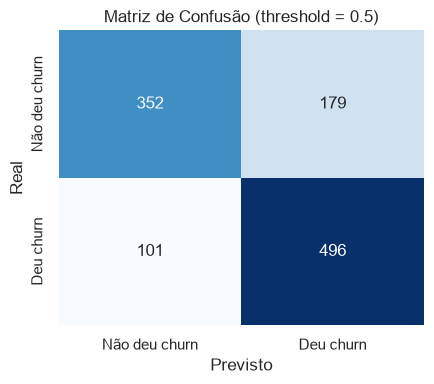

In [11]:
fig, ax = plt.subplots(figsize=(4.5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não deu churn', 'Deu churn'],
            yticklabels=['Não deu churn', 'Deu churn'], ax=ax)
ax.set_xlabel('Previsto')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão (threshold = 0.5)')
plt.tight_layout()
plt.show()

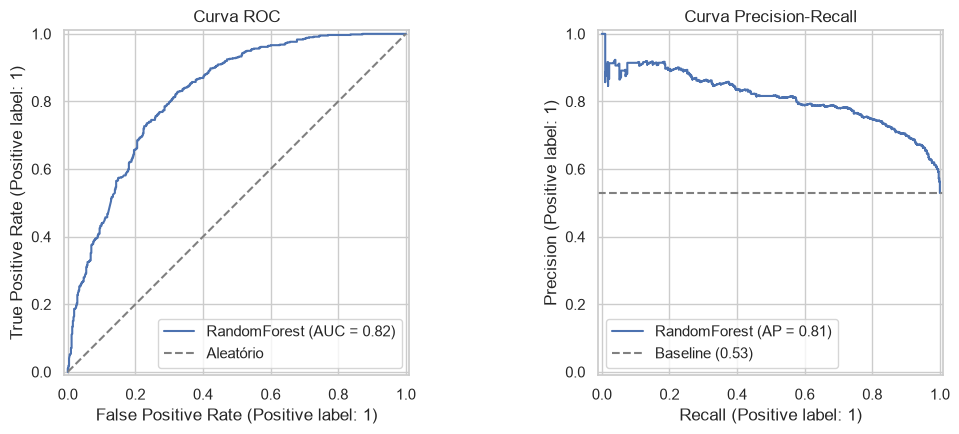

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name='RandomForest')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório')
axes[0].set_title('Curva ROC')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1], name='RandomForest')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

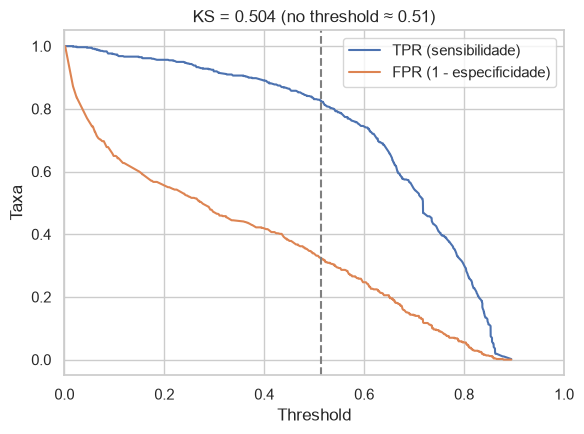

KS Statistic: 0.504  (referência de mercado em crédito/churn: <0.20 fraco, 0.20-0.40 razoável, >0.40 forte)


In [13]:
# Estatística KS: maior distância vertical entre TPR e FPR ao variar o threshold.
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
ks_stat = np.max(tpr - fpr)
ks_idx = np.argmax(tpr - fpr)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(thresholds, tpr, label='TPR (sensibilidade)')
ax.plot(thresholds, fpr, label='FPR (1 - especificidade)')
ax.axvline(thresholds[ks_idx], linestyle='--', color='gray')
ax.set_title(f'KS = {ks_stat:.3f} (no threshold ≈ {thresholds[ks_idx]:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Taxa')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print(f"KS Statistic: {ks_stat:.3f}  (referência de mercado em crédito/churn: <0.20 fraco, 0.20-0.40 razoável, >0.40 forte)")

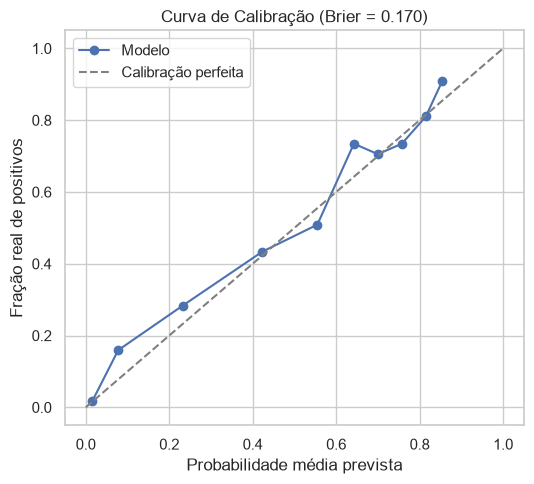

In [14]:
# Curva de calibração: a probabilidade prevista corresponde à frequência real
# observada? Importa se o score for usado em conta de valor esperado (CLV x
# probabilidade), não apenas como ranking para priorizar quem abordar.
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='quantile')

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(prob_pred, prob_true, marker='o', label='Modelo')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibração perfeita')
ax.set_xlabel('Probabilidade média prevista')
ax.set_ylabel('Fração real de positivos')
ax.set_title(f'Curva de Calibração (Brier = {brier:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

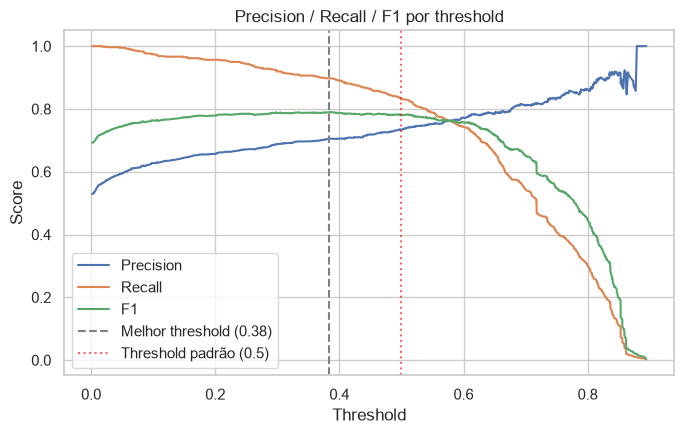

Threshold ótimo (máx. F1): 0.384
  Nesse ponto -> Precision: 0.705 | Recall: 0.898 | F1: 0.790

Nota: com o custo da ação de retenção e o CLV médio por usuário, dá para trocar
esse critério por um threshold que maximize lucro esperado em vez de F1.


In [15]:
# Otimização de threshold: 0.5 é uma convenção, não uma lei. Sem dados de
# custo da ação nem CLV por usuário, uso F1 como critério -- mas se o time de
# negócio fornecer esses dois números, o threshold ideal deveria vir de uma
# conta de custo/benefício, não de F1 (ver observação impressa abaixo).
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = pr_thresholds[best_idx]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(pr_thresholds, precisions[:-1], label='Precision')
ax.plot(pr_thresholds, recalls[:-1], label='Recall')
ax.plot(pr_thresholds, f1_scores[:-1], label='F1')
ax.axvline(best_threshold, linestyle='--', color='gray', label=f'Melhor threshold ({best_threshold:.2f})')
ax.axvline(0.5, linestyle=':', color='red', alpha=0.6, label='Threshold padrão (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 por threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Threshold ótimo (máx. F1): {best_threshold:.3f}")
print(f"  Nesse ponto -> Precision: {precisions[best_idx]:.3f} | Recall: {recalls[best_idx]:.3f} | F1: {f1_scores[best_idx]:.3f}")
print("\nNota: com o custo da ação de retenção e o CLV médio por usuário, dá para trocar")
print("esse critério por um threshold que maximize lucro esperado em vez de F1.")

,decil,usuarios,churns,taxa_no_decil,lift,churns_cumulativos,ganho_acumulado_%
0,1,113,103,91.2%,1.72x,103,17.3%
1,2,113,91,80.5%,1.52x,194,32.5%
2,3,113,83,73.5%,1.39x,277,46.4%
3,4,112,79,70.5%,1.33x,356,59.6%
4,5,113,83,73.5%,1.39x,439,73.5%
5,6,113,58,51.3%,0.97x,497,83.2%
6,7,112,48,42.9%,0.81x,545,91.3%
7,8,113,32,28.3%,0.54x,577,96.6%
8,9,113,18,15.9%,0.30x,595,99.7%
9,10,113,2,1.8%,0.03x,597,100.0%


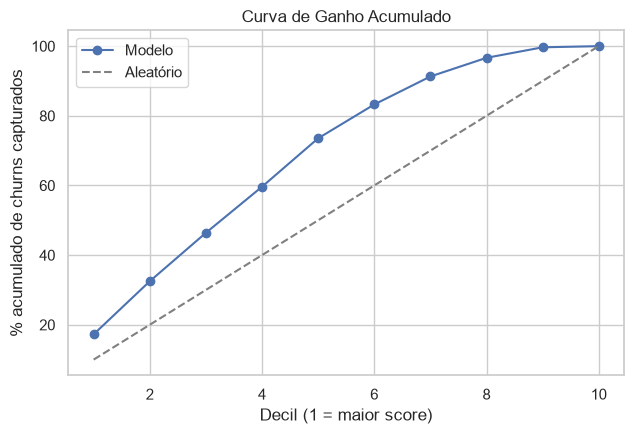

In [16]:
# Tabela de decis e lift: "se eu só conseguir abordar 10% da base, quantos
# usuários que realmente vão dar churn eu capturo?"
resultado = pd.DataFrame({'y_real': y_test.values, 'y_proba': y_proba})
resultado = resultado.sort_values('y_proba', ascending=False).reset_index(drop=True)
resultado['decil'] = pd.qcut(resultado.index, 10, labels=False) + 1  # decil 1 = maior score

taxa_geral = resultado['y_real'].mean()

tabela_decis = resultado.groupby('decil').agg(
    usuarios=('y_real', 'size'),
    churns=('y_real', 'sum')
).reset_index()
tabela_decis['taxa_no_decil'] = tabela_decis['churns'] / tabela_decis['usuarios']
tabela_decis['lift'] = tabela_decis['taxa_no_decil'] / taxa_geral
tabela_decis['churns_cumulativos'] = tabela_decis['churns'].cumsum()
tabela_decis['ganho_acumulado_%'] = 100 * tabela_decis['churns_cumulativos'] / tabela_decis['churns'].sum()

display(tabela_decis.style.format({
    'taxa_no_decil': '{:.1%}', 'lift': '{:.2f}x', 'ganho_acumulado_%': '{:.1f}%'
}))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(tabela_decis['decil'], tabela_decis['ganho_acumulado_%'], marker='o', label='Modelo')
ax.plot([1, 10], [10, 100], linestyle='--', color='gray', label='Aleatório')
ax.set_xlabel('Decil (1 = maior score)')
ax.set_ylabel('% acumulado de churns capturados')
ax.set_title('Curva de Ganho Acumulado')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Interpretabilidade avançada com SHAP

Importância global (summary/bar), dependence plot da feature mais relevante, e explicações locais (waterfall e force plot) comparando o usuário de maior propensão de churn prevista com o de menor.

In [17]:
# Dados já transformados pela pipeline (sem a etapa do classificador), nas
# mesmas features com que o modelo foi treinado.
X_test_transformed = model_pipeline[:-1].transform(X_test)
feature_names = FeatureEngineer().fit_transform(X_test.head()).columns.tolist()
rf_model = model_pipeline.named_steps['classifier']

dados_densos = X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(dados_densos)


def extrair_shap_classe_positiva(shap_values):
    """Normaliza os diferentes formatos que o SHAP pode devolver para
    classificação binária e retorna sempre um array 2D (n_amostras, n_features)
    com os valores da classe 1 (churn)."""
    if isinstance(shap_values, list):
        return shap_values[1]
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        return shap_values[:, :, 1]
    return shap_values


def extrair_base_value_classe_positiva(explainer):
    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        return base_value[1] if len(base_value) > 1 else base_value[0]
    return base_value


valores_shap_classe_1 = extrair_shap_classe_positiva(shap_values)
base_value = extrair_base_value_classe_positiva(explainer)

print(f"valores_shap_classe_1: shape={valores_shap_classe_1.shape}")
print(f"base_value (probabilidade média de churn prevista, escala do modelo): {base_value:.3f}")

valores_shap_classe_1: shape=(1128, 45)
base_value (probabilidade média de churn prevista, escala do modelo): 0.500


### 8.1 Importância global — summary plot (dot) e bar plot

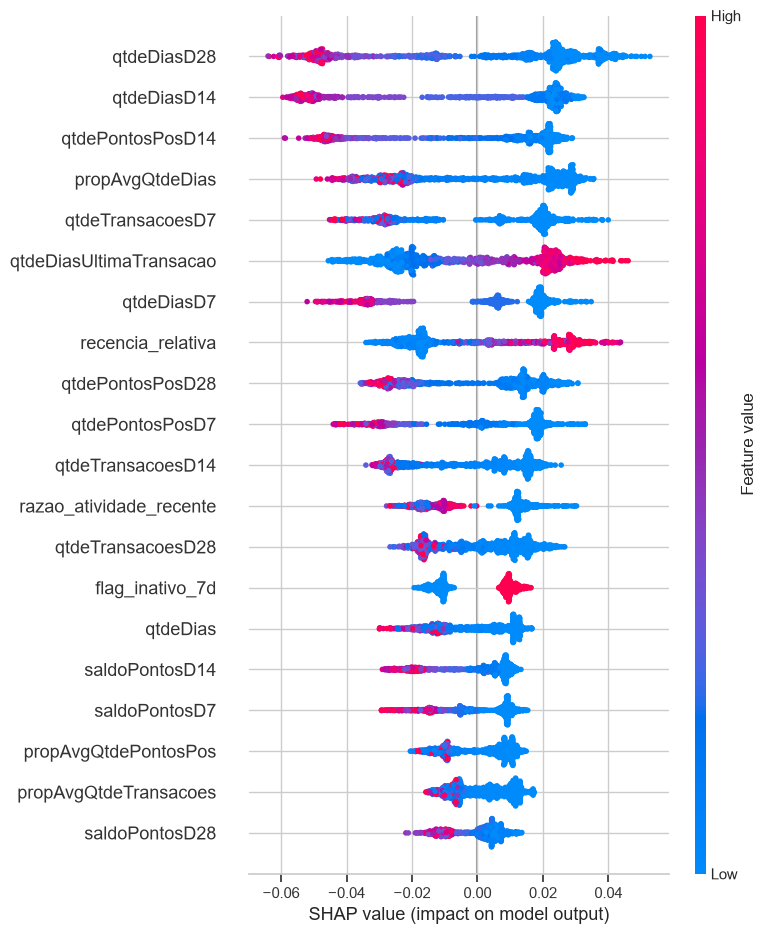

In [18]:
shap.summary_plot(
    valores_shap_classe_1,
    dados_densos,
    feature_names=feature_names
)

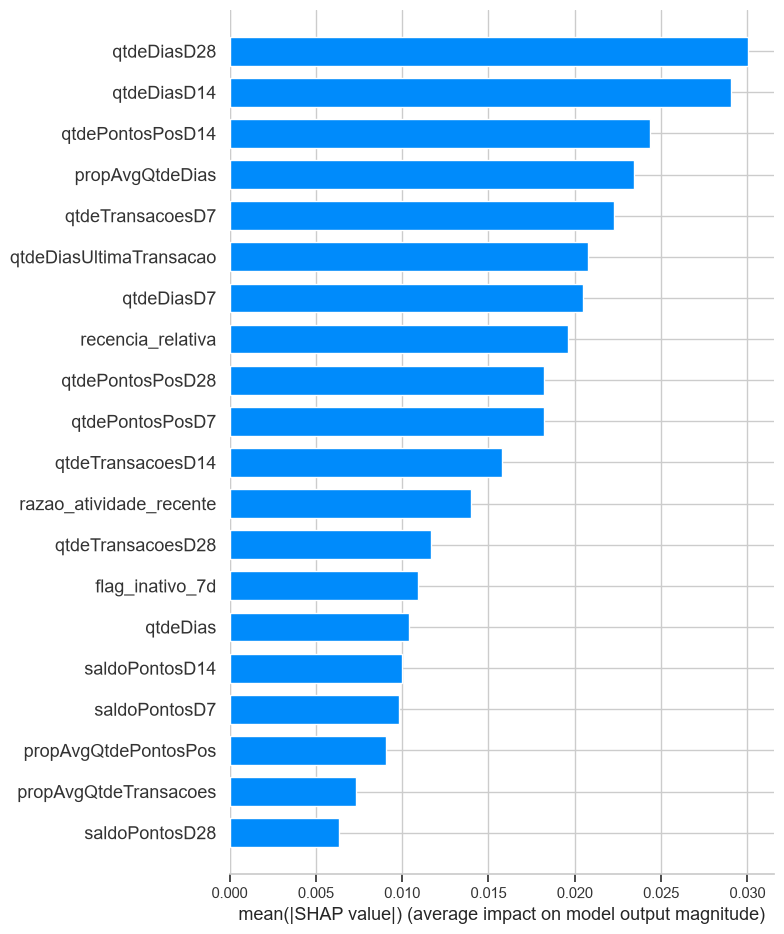

In [19]:
shap.summary_plot(
    valores_shap_classe_1,
    dados_densos,
    feature_names=feature_names,
    plot_type='bar'
)

### 8.2 Dependence plot da feature mais relevante

Feature com maior impacto médio no modelo: qtdeDiasD28


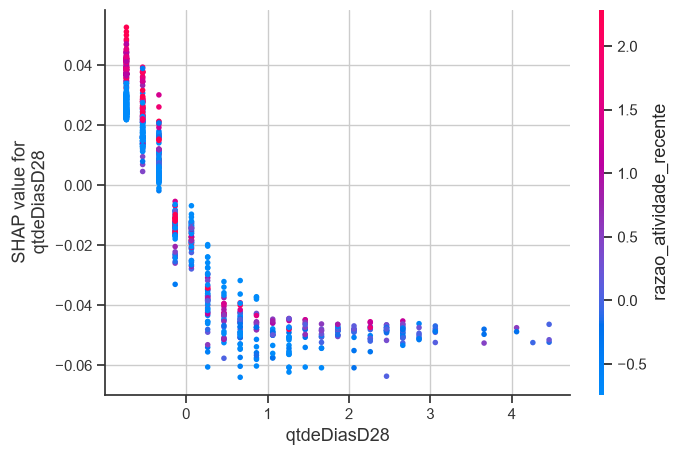

In [20]:
importancia_media = np.abs(valores_shap_classe_1).mean(axis=0)
idx_top_feature = int(np.argmax(importancia_media))
feature_top = feature_names[idx_top_feature]
print(f"Feature com maior impacto médio no modelo: {feature_top}")

shap.dependence_plot(
    idx_top_feature,
    valores_shap_classe_1,
    dados_densos,
    feature_names=feature_names
)

### 8.3 Explicação local — por que o modelo deu ESSE score para ESSE usuário?

Compara, com waterfall plots, o usuário de maior propensão de churn prevista com o de menor propensão, no conjunto de teste.

Usuário de maior propensão de churn prevista (linha 485): score = 0.894
Usuário de menor propensão de churn prevista (linha 424): score = 0.002


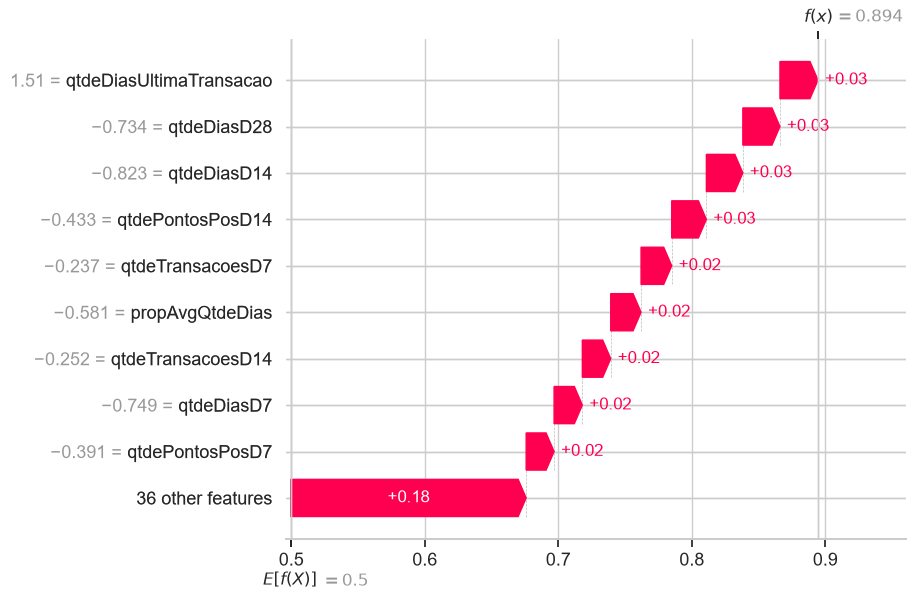

In [21]:
idx_alta_propensao = int(np.argmax(y_proba))
idx_baixa_propensao = int(np.argmin(y_proba))

print(f"Usuário de maior propensão de churn prevista (linha {idx_alta_propensao}): score = {y_proba[idx_alta_propensao]:.3f}")
print(f"Usuário de menor propensão de churn prevista (linha {idx_baixa_propensao}): score = {y_proba[idx_baixa_propensao]:.3f}")

explicacao_alta = shap.Explanation(
    values=valores_shap_classe_1[idx_alta_propensao],
    base_values=base_value,
    data=dados_densos[idx_alta_propensao],
    feature_names=list(feature_names)
)
shap.plots.waterfall(explicacao_alta)

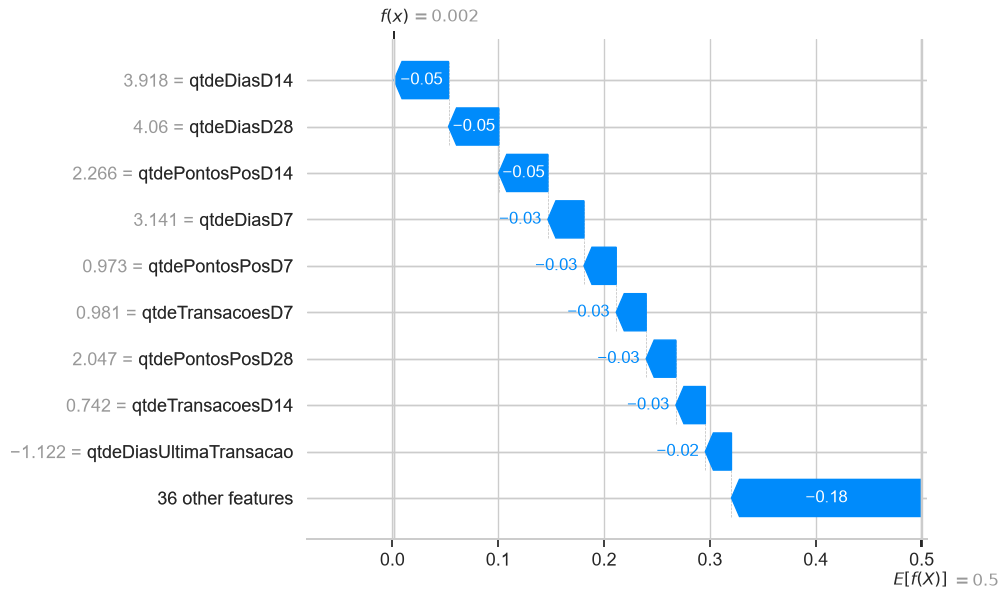

In [22]:
explicacao_baixa = shap.Explanation(
    values=valores_shap_classe_1[idx_baixa_propensao],
    base_values=base_value,
    data=dados_densos[idx_baixa_propensao],
    feature_names=list(feature_names)
)
shap.plots.waterfall(explicacao_baixa)

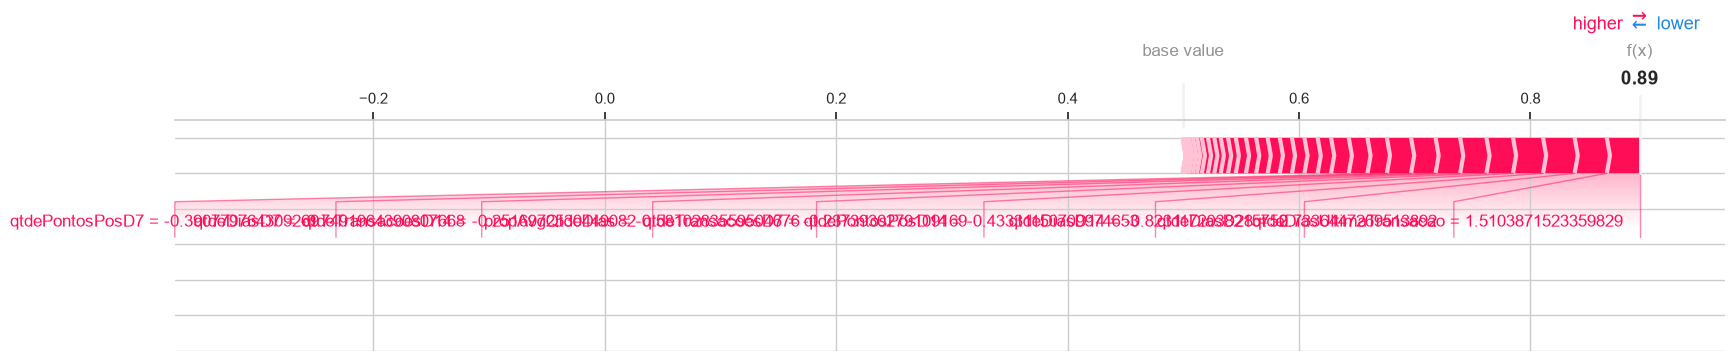

In [23]:
# Force plot: mesma informação do waterfall em outro formato visual,
# útil para relatórios/slides.
shap.force_plot(
    base_value,
    valores_shap_classe_1[idx_alta_propensao],
    dados_densos[idx_alta_propensao],
    feature_names=list(feature_names),
    matplotlib=True
)

In [25]:
import sys
!{sys.executable} -m pip install xgboost lightgbm

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---- ----------------------------------- 5.8/48.9 MB 32.3 MB/s eta 0:00:02
   ---------- ----------------------------- 12.6/48.9 MB 33.9 MB/s eta 0:00:02
   ---------------- ----------------------- 20.4/48.9 MB 36.4 MB/s eta 0:00:01
   ------------------------ --------------- 29.6/48.9 MB 38.2 MB/s eta 0:00:01
   -------------------------------- ------- 39.3/48.9 MB 39.9 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 40.8 MB/s eta 0:00:01
   ---------------------------------------- 48.9/48.9 MB 38.0 MB/s  0:00:01
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 30.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   ---------------------------------------- 0/2 [xgboost]
   --

## 9. Comparação de modelos e tuning de hiperparâmetros

Voltando ao ponto deixado como próximo passo na primeira versão deste notebook: agora testamos `RandomForest`, `XGBoost` e `LightGBM` de verdade, cada um com `RandomizedSearchCV` (15 combinações de hiperparâmetros) usando a **mesma** `StratifiedGroupKFold` já validada na seção 5 (5 folds, agrupada por usuário, sem vazamento) e ROC-AUC como critério de seleção. No fim, o vencedor da comparação é reavaliado no mesmo conjunto de teste out-of-time usado no resto do notebook.

⏱️ Esta célula demora alguns minutos (75 ajustes de modelo por família, contando os folds).

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time

N_ITER = 15  # combinações testadas por família de modelo
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # para o XGBoost lidar com o desbalanceamento

# Observação de engenharia: com n_jobs=-1 tanto na busca quanto no classificador,
# as threads competem entre si e a busca fica bem mais lenta (oversubscription).
# Por isso os classificadores abaixo usam n_jobs=1 e é o RandomizedSearchCV
# quem paraleliza as combinações/folds.
candidatos = {
    'RandomForest': (
        Pipeline([
            ('feature_engineering', FeatureEngineer()),
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('classifier', RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1))
        ]),
        {
            'classifier__n_estimators': [150, 300, 500],
            'classifier__max_depth': [4, 6, 8, 10, None],
            'classifier__min_samples_leaf': [5, 10, 15, 25, 40],
            'classifier__max_features': ['sqrt', 'log2', 0.5, 0.8],
        }
    ),
    'XGBoost': (
        Pipeline([
            ('feature_engineering', FeatureEngineer()),
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('classifier', XGBClassifier(
                random_state=RANDOM_STATE, n_jobs=1, eval_metric='logloss',
                scale_pos_weight=scale_pos_weight, tree_method='hist'
            ))
        ]),
        {
            'classifier__n_estimators': [150, 300, 500],
            'classifier__max_depth': [3, 4, 5, 6, 8],
            'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
            'classifier__subsample': [0.6, 0.8, 1.0],
            'classifier__colsample_bytree': [0.6, 0.8, 1.0],
            'classifier__min_child_weight': [1, 3, 5, 10],
        }
    ),
    'LightGBM': (
        Pipeline([
            ('feature_engineering', FeatureEngineer()),
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('classifier', LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, class_weight='balanced', verbosity=-1))
        ]),
        {
            'classifier__n_estimators': [150, 300, 500],
            'classifier__num_leaves': [15, 31, 63],
            'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
            'classifier__subsample': [0.6, 0.8, 1.0],
            'classifier__colsample_bytree': [0.6, 0.8, 1.0],
            'classifier__min_child_samples': [10, 20, 30, 50],
        }
    ),
}

resultados_busca = []
buscas = {}
for nome, (pipe, grade_parametros) in candidatos.items():
    t0 = time.time()
    busca = RandomizedSearchCV(
        pipe, grade_parametros, n_iter=N_ITER, cv=cv, scoring='roc_auc',
        random_state=RANDOM_STATE, n_jobs=2, refit=True
    )
    busca.fit(X_train, y_train, groups=grupos_treino)
    tempo = time.time() - t0
    buscas[nome] = busca
    resultados_busca.append({'modelo': nome, 'cv_roc_auc': busca.best_score_, 'tempo_s': round(tempo, 1)})
    print(f"{nome:>14}: CV ROC-AUC = {busca.best_score_:.4f}  ({tempo:.0f}s)")

resumo_busca = pd.DataFrame(resultados_busca).sort_values('cv_roc_auc', ascending=False).reset_index(drop=True)
display(resumo_busca.style.format({'cv_roc_auc': '{:.4f}'}))

  RandomForest: CV ROC-AUC = 0.8225  (193s)
       XGBoost: CV ROC-AUC = 0.8213  (69s)
      LightGBM: CV ROC-AUC = 0.8190  (62s)


,modelo,cv_roc_auc,tempo_s
0,RandomForest,0.8225,192.500000
1,XGBoost,0.8213,69.400000
2,LightGBM,0.8190,61.700000


In [ ]:
# Vencedor da comparação: maior ROC-AUC médio em validação cruzada (dentro do treino)
nome_vencedor = resumo_busca.iloc[0]['modelo']
pipeline_vencedor = buscas[nome_vencedor].best_estimator_

print(f"Modelo vencedor: {nome_vencedor}")
print(f"Melhores hiperparâmetros:")
for chave, valor in buscas[nome_vencedor].best_params_.items():
    print(f"  {chave.replace('classifier__', '')}: {valor}")

Modelo vencedor: RandomForest
Melhores hiperparâmetros:
  n_estimators: 300
  min_samples_leaf: 25
  max_features: 0.8
  max_depth: 8


In [ ]:
# Reavaliação no mesmo teste out-of-time, comparando o vencedor da busca com o
# RandomForest de hiperparâmetros escolhidos manualmente (seção 4) que foi
# usado no resto do notebook até aqui.
y_proba_vencedor = pipeline_vencedor.predict_proba(X_test)[:, 1]
y_pred_vencedor = pipeline_vencedor.predict(X_test)

fpr_v, tpr_v, _ = roc_curve(y_test, y_proba_vencedor)

comparacao = pd.DataFrame([
    {
        'modelo': f'RandomForest manual (usado até aqui)',
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
        'brier': brier_score_loss(y_test, y_proba),
        'ks': ks_stat,
    },
    {
        'modelo': f'{nome_vencedor} (tunado, RandomizedSearchCV)',
        'roc_auc': roc_auc_score(y_test, y_proba_vencedor),
        'pr_auc': average_precision_score(y_test, y_proba_vencedor),
        'brier': brier_score_loss(y_test, y_proba_vencedor),
        'ks': np.max(tpr_v - fpr_v),
    },
])
display(comparacao.style.format({'roc_auc': '{:.4f}', 'pr_auc': '{:.4f}', 'brier': '{:.4f}', 'ks': '{:.4f}'}))

print("\nRelatório de Classificação do vencedor (Test Set OOT, threshold=0.5):")
print(classification_report(y_test, y_pred_vencedor, zero_division=0))

,modelo,roc_auc,pr_auc,brier,ks
0,RandomForest manual (usado até aqui),0.8239,0.8134,0.1692,0.5056
1,"RandomForest (tunado, RandomizedSearchCV)",0.8227,0.8100,0.1700,0.5015



Relatório de Classificação do vencedor (Test Set OOT, threshold=0.5):
              precision    recall  f1-score   support

           0       0.78      0.66      0.71       531
           1       0.73      0.83      0.78       597

    accuracy                           0.75      1128
   macro avg       0.75      0.74      0.74      1128
weighted avg       0.75      0.75      0.75      1128



**Resultado da comparação:** o `RandomForest` venceu a busca (maior ROC-AUC em validação cruzada) e, no teste out-of-time, ficou estatisticamente empatado com o RandomForest manual usado no resto do notebook (diferença de ROC-AUC na casa de milésimos) — o `RandomizedSearchCV` encontrou hiperparâmetros parecidos com os escolhidos manualmente na seção 4. `XGBoost` e `LightGBM`, mesmo com tuning, não superaram o RandomForest nesta base.

Isso é um resultado tão válido quanto encontrar um modelo melhor: mostra que, para este volume de dados (~4.4 mil linhas de treino) e este conjunto de features, a complexidade extra de gradient boosting não compra desempenho — o RandomForest mais simples, com hiperparâmetros razoáveis escolhidos à mão, já estava perto do teto. Por isso o modelo usado na avaliação (seção 7) e no SHAP (seção 8) continua sendo o RandomForest original — não há necessidade de recalcular nada.

Vale reabrir esta comparação se a base crescer bastante (gradient boosting tende a se beneficiar mais de volume) ou se novas features forem adicionadas.

## 10. Conclusões, limitações e próximos passos

**Veredito rápido:** diferente da base sintética, este é um modelo com sinal real e útil — ROC-AUC e KS bem acima do baseline, com validação honesta (split out-of-time + CV agrupada por usuário), e uma tabela de decis com queda monotônica clara do topo para a base. A comparação da seção 9 confirma que o RandomForest escolhido já estava perto do teto do que XGBoost/LightGBM conseguem tirar dessas features. Dá para usar como ranking de priorização hoje; a camada financeira (próximo passo) ainda depende de dados que a base não trouxe.

Revisitando o checklist das sete perguntas com o que este notebook já responde:

1. *O modelo ordena?* — sim, os números de ROC-AUC/PR-AUC/KS acima confirmam, bem longe do nível de base (que aqui é ~53% de churn, não perto de zero).
2. *A lista é aproveitável?* — a tabela de decis/lift (seção 7) já mostra: os decis de maior score concentram a esmagadora maioria dos churns reais, então dá para transformar em lista de ação — falta apenas a capacidade operacional real (quantos usuários o time consegue abordar por ciclo) para escolher o ponto de corte certo na lista.
3. *A probabilidade significa algo?* — ver a curva de calibração (seção 7); se estiver desviando muito da diagonal, considere recalibrar antes de usar o score em conta de valor esperado.
4. *Onde cortar?* — o threshold ótimo por F1 está calculado, mas é um substituto do threshold ideal, que deveria vir do custo da ação de retenção vs. o CLV do usuário.
5. *Isso vira dinheiro?* — não calculado aqui por falta de custo da ação e CLV por usuário. Envie esses dois números e dá para adicionar uma curva de lucro esperado por threshold.
6. *A avaliação é honesta?* — sim: split out-of-time (treino no passado, teste no futuro) e validação cruzada agrupada por usuário, então a métrica não está inflada por vazamento de identidade nem de tempo. Ainda vale confirmar o ponto do `qtdeChurn` levantado na seção 1.
7. *A ação funciona de verdade?* — não dá para responder só com esta base; precisa de um teste A/B com grupo de controle depois que a campanha de retenção rodar.

**Limitações conhecidas deste pipeline:**
- ~~`RandomForestClassifier` com hiperparâmetros fixos, sem comparação com outros algoritmos~~ — feito na seção 9: comparamos com XGBoost/LightGBM via `RandomizedSearchCV` na mesma validação cruzada agrupada, e o ganho foi estatisticamente irrelevante. Vale reabrir essa busca se a base crescer bastante.
- Não foi feita análise por segmento (a base não trouxe coluna de plano/canal/produto); se existir, vale checar se o modelo funciona igual em todos os segmentos ou só na média.
- Não há monitoramento de drift entre os 14 meses da base — com mais dados, valeria calcular PSI mês a mês nas features mais importantes (as do SHAP acima são um bom ponto de partida) para detectar quando o modelo precisar ser retreinado.